In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from confrdm_jax.simulators.crdm_utils import normalized_gamma_derivative

In [7]:
def simulate_rdm_trajectories(v0, v1, s0, s1, b, n_trials, dt, t_max, seed=42):
    """Simulate RDM evidence accumulation via Euler-Maruyama.
    
    Returns individual trial trajectories (full paths up to decision)
    and the mean (noiseless) trajectories.
    """
    rng = np.random.default_rng(seed)
    n_steps = int(t_max / dt)
    t = np.arange(1, n_steps + 1) * dt

    v = np.array([v0, v1])
    s = np.array([s0, s1])

    trials = []
    for _ in range(n_trials):
        noise = rng.standard_normal((2, n_steps))
        # Euler-Maruyama: dx = v*dt + s*dW
        increments = v[:, None] * dt + s[:, None] * noise * np.sqrt(dt)
        x = np.cumsum(increments, axis=1)  # shape (2, n_steps)

        # First-passage time detection
        crossed = x >= b
        first_idx = np.argmax(crossed, axis=1)
        did_cross = crossed.any(axis=1)
        fpt = np.where(did_cross, (first_idx + 1) * dt, np.inf)

        winner = int(np.argmin(fpt))
        rt_decision = float(fpt[winner])
        end_idx = min(int(rt_decision / dt) + 1, n_steps) if rt_decision < np.inf else n_steps

        trials.append({
            'x': x,
            'end_idx': end_idx,
            'winner': winner,
            'rt_decision': rt_decision,
        })

    # Mean (noiseless) trajectories — simple linear drift
    x0_mean = v0 * t
    x1_mean = v1 * t

    return trials, t, x0_mean, x1_mean


def simulate_crdm_trajectories(v0, v1, amp, tau, s0, s1, b, n_trials, dt, t_max, seed=42):
    """Simulate CRDM evidence accumulation with gamma conflict pulse on accumulator 1.
    
    Mirrors simulate_crdm_dataset in src/confrdm_jax/simulators/crdm.py.
    Congruent condition: pulse added to accumulator 1 (correct/fast response).
    """
    rng = np.random.default_rng(seed)
    n_steps = int(t_max / dt)
    t = np.arange(1, n_steps + 1) * dt

    s = np.array([s0, s1])

    # Time-varying drift: acc 0 constant, acc 1 gets the pulse
    pulse = np.asarray(normalized_gamma_derivative(t, amp, tau, a_shape=2.0))
    mu0 = np.full(n_steps, v0)
    mu1 = v1 + pulse
    mu = np.stack([mu0, mu1])  # (2, n_steps)

    trials = []
    for _ in range(n_trials):
        noise = rng.standard_normal((2, n_steps))
        increments = mu * dt + s[:, None] * noise * np.sqrt(dt)
        x = np.cumsum(increments, axis=1)

        crossed = x >= b
        first_idx = np.argmax(crossed, axis=1)
        did_cross = crossed.any(axis=1)
        fpt = np.where(did_cross, (first_idx + 1) * dt, np.inf)

        winner = int(np.argmin(fpt))
        rt_decision = float(fpt[winner])
        end_idx = min(int(rt_decision / dt) + 1, n_steps) if rt_decision < np.inf else n_steps

        trials.append({
            'x': x,
            'end_idx': end_idx,
            'winner': winner,
            'rt_decision': rt_decision,
        })

    # Mean (noiseless) trajectories
    x0_mean = np.cumsum(mu0 * dt)
    x1_mean = np.cumsum(mu1 * dt)

    return trials, t, x0_mean, x1_mean, pulse

In [8]:
# ============================================================
# Parameters
# ============================================================

# Shared / RDM parameters
v0  = 1.0   # drift rate for accumulator 0 (incorrect/slow response)
v1  = 2.0   # drift rate for accumulator 1 (correct/fast response)
s0  = 1.0   # diffusion coefficient acc 0 (fixed by convention)
s1  = 0.8   # diffusion coefficient acc 1 (free parameter s_true)
b   = 1.5   # decision boundary
t0  = 0.20  # non-decision time (s)

# CRDM-only parameters (congruent condition: pulse aids acc 1)
amp = 0.20  # conflict pulse amplitude
tau = 0.15  # conflict pulse time constant (s)

# Simulation settings
dt      = 0.002
t_max   = 2.0
n_trials = 10
SEED = 7

rdm_trials,  t, rdm_x0,  rdm_x1          = simulate_rdm_trajectories(
    v0, v1, s0, s1, b, n_trials, dt, t_max, seed=SEED
)
crdm_trials, _, crdm_x0, crdm_x1, pulse  = simulate_crdm_trajectories(
    v0, v1, amp, tau, s0, s1, b, n_trials, dt, t_max, seed=SEED
)

print(f"RDM  — winner counts  acc0:{sum(tr['winner']==0 for tr in rdm_trials):2d}  "
      f"acc1:{sum(tr['winner']==1 for tr in rdm_trials):2d}")
print(f"CRDM — winner counts  acc0:{sum(tr['winner']==0 for tr in crdm_trials):2d}  "
      f"acc1:{sum(tr['winner']==1 for tr in crdm_trials):2d}")

RDM  — winner counts  acc0: 3  acc1: 7
CRDM — winner counts  acc0: 3  acc1: 7


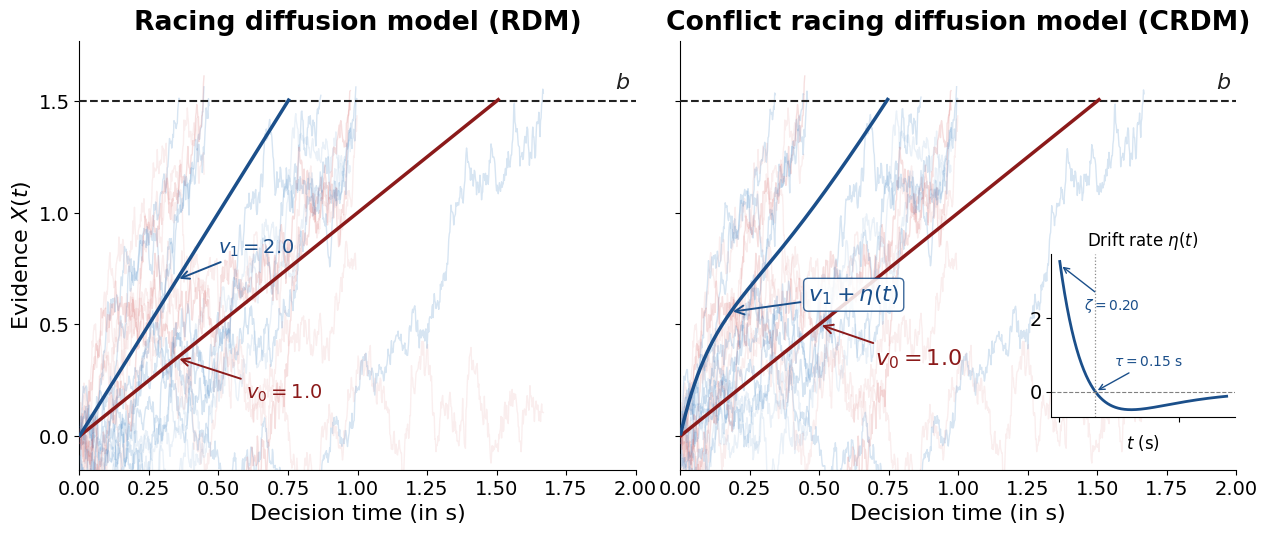

In [14]:
# ============================================================
# Figure
# ============================================================

plt.rcParams.update({
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    "font.size": 16,
    "axes.labelsize": 16,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

C0        = '#D45F5F'   # accumulator 0 (slow / incorrect)
C1        = '#3A7FC1'   # accumulator 1 (fast / correct)
C0_DARK   = '#8B1A1A'
C1_DARK   = '#1B4F8A'
ALPHA_IND = 0.1        # individual trial transparency
LW_IND    = 1.0
LW_MEAN   = 2.5

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), sharey=True)
fig.subplots_adjust(wspace=0.08, left=0.08, right=0.97, top=0.90, bottom=0.12)


# ----------------------------------------------------------------
# Shared drawing routine
# ----------------------------------------------------------------
def draw_accumulation_panel(ax, trials, t, x0_mean, x1_mean, b, s0, s1):
    """Draw individual trials and mean trajectories for one model."""

    # --- Boundary -------------------------------------------------
    ax.axhline(b, color='#222', lw=1.5, ls='--', zorder=4)

    # --- Individual trials ----------------------------------------
    for tr in trials:
        e = tr['end_idx']
        w = tr['winner']
        t_e = t[:e]
        # Losing accumulator first (drawn behind)
        loser = 1 - w
        ax.plot(t_e, tr['x'][loser, :e], color=(C0 if loser == 0 else C1),
                lw=LW_IND, alpha=ALPHA_IND, zorder=2)
        # Winning accumulator on top
        ax.plot(t_e, tr['x'][w, :e], color=(C0 if w == 0 else C1),
                lw=LW_IND, alpha=ALPHA_IND + 0.10, zorder=3)
        # Decision dot
        # hit_x = min(tr['x'][w, e - 1], b) if e > 0 else b
        # ax.scatter([t[e - 1]], [hit_x],
        #            color=(C0_DARK if w == 0 else C1_DARK),
        #            s=22, zorder=6, alpha=0.75, linewidths=0)

    # --- Mean trajectories ----------------------------------------
    for x_mean, c_dark, label in [
        (x0_mean, C0_DARK, r'$\bar{x}_0(t)$'),
        (x1_mean, C1_DARK, r'$\bar{x}_1(t)$'),
    ]:
        mask = x_mean <= b * 1.005
        ax.plot(t[mask], x_mean[mask], color=c_dark, lw=LW_MEAN, zorder=7, label=label)


# ==================================================================
# LEFT PANEL — Racing Diffusion Model
# ==================================================================
ax = axes[0]
ax.set_title('Racing diffusion model (RDM)', fontweight='bold', pad=8)

draw_accumulation_panel(ax, rdm_trials, t, rdm_x0, rdm_x1, b, s0, s1)

# --- Parameter annotations ----------------------------------------

# Boundary b
ax.text(t_max * 0.99, b + 0.04, r'$b$', ha='right', va='bottom',
        fontweight='bold', color='#222')

# Drift rates v0, v1 — annotate slope of mean trajectories
t_ann = 0.35
ax.annotate(
    r'$v_0 = %.1f$' % v0,
    xy=(t_ann, v0 * t_ann),
    xytext=(t_ann + 0.25, v0 * t_ann - 0.18),
    fontsize=14, color=C0_DARK,
    arrowprops=dict(arrowstyle='->', color=C0_DARK, lw=1.4),
)
ax.annotate(
    r'$v_1 = %.1f$' % v1,
    xy=(t_ann, v1 * t_ann),
    xytext=(t_ann + 0.15, v1 * t_ann + 0.12),
    fontsize=14, color=C1_DARK,
    arrowprops=dict(arrowstyle='->', color=C1_DARK, lw=1.4),
)

ax.set_xlabel('Decision time (in s)')
ax.set_ylabel('Evidence $X(t)$')
ax.set_xlim(0, t_max)
ax.set_ylim(-0.15, b * 1.18)
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.legend(loc='upper left', framealpha=0.7)


# ==================================================================
# RIGHT PANEL — Conflict RDM
# ==================================================================
ax = axes[1]
ax.set_title('Conflict racing diffusion model (CRDM)', fontweight='bold', pad=8)

draw_accumulation_panel(ax, crdm_trials, t, crdm_x0, crdm_x1, b, s0, s1)

# --- Boundary b
ax.text(t_max * 0.99, b + 0.04, r'$b$', ha='right', va='bottom',
        fontweight='bold', color='#222')

# --- Annotate conflict accumulator drift (arrow points to early steep rise)
t_early = 0.18
t_idx_early = int(t_early / dt)
ax.annotate(
    r'$v_1 + \eta(t)$',
    xy=(t_early, crdm_x1[t_idx_early]),
    xytext=(t_early + 0.28, crdm_x1[t_idx_early] + 0.05),
    color=C1_DARK,
    arrowprops=dict(arrowstyle='->', color=C1_DARK, lw=1.4, zorder=10),
    bbox=dict(boxstyle='round,pad=0.2', fc='white', ec=C1_DARK, alpha=0.85),
    zorder=10,
)

# Acc 0 unchanged: same annotation as RDM
t_ann2 = 0.50
ax.annotate(
    r'$v_0 = %.1f$' % v0,
    xy=(t_ann2, v0 * t_ann2),
    xytext=(t_ann2 + 0.20, v0 * t_ann2 - 0.18),
    color=C0_DARK,
    arrowprops=dict(arrowstyle='->', color=C0_DARK, lw=1.4),
)

# --- Inset: conflict pulse v_a(t) ---------------------------------
ax_inset = inset_axes(
    ax, width='33%', height='38%',
    bbox_to_anchor=(0.65, 0.1, 1, 1),
    bbox_transform=ax.transAxes,
    loc='lower left',
)

t_pulse_plot = t[t <= 0.70]
pulse_plot   = normalized_gamma_derivative(t_pulse_plot, amp, tau, a_shape=2.0)

ax_inset.plot(t_pulse_plot, pulse_plot, color=C1_DARK, lw=2.0)
ax_inset.axhline(0, color='gray', lw=0.8, ls='--')

# Mark amplitude at early peak
peak_idx  = int(np.argmax(pulse_plot[1:]) + 1)   # skip t=0
t_peak    = t_pulse_plot[peak_idx]
va_peak   = pulse_plot[peak_idx]
ax_inset.annotate(
    r'$\zeta=%.2f$' % amp,
    xy=(t_peak, va_peak),
    xytext=(t_peak + 0.10, va_peak * 0.65),
    fontsize=10, color=C1_DARK,
    arrowprops=dict(arrowstyle='->', color=C1_DARK, lw=1.0),
)

# Mark tau (zero-crossing)
ax_inset.axvline(tau, color='#888', lw=0.9, ls=':')
# ax_inset.text(tau + 0.05, pulse_plot.min() * 0.5,
#               r'$\tau = %.2f$ s' % tau, fontsize=10, color='#555')

ax_inset.annotate(
    r'$\tau = %.2f$ s' % tau,
    xy=(tau, 0.0),
    xytext=(tau + 0.08, 0.7),
    fontsize=10, color=C1_DARK,
    arrowprops=dict(arrowstyle='->', color=C1_DARK, lw=1.0),
)

ax_inset.set_title(r'Drift rate $\eta(t)$', fontsize=12)
ax_inset.set_xlabel('$t$ (s)', fontsize=12)
ax_inset.set_ylabel('', fontsize=12)
ax_inset.set_xticklabels([])
# ax_inset.set_yticklabels([])
ax_inset.spines[['top', 'right']].set_visible(False)

ax.set_xlabel('Decision time (in s)')
ax.set_xlim(0, t_max)
ax.legend(loc='upper left', framealpha=0.7)

# Remove individual panel legends
for ax in axes:
    ax.get_legend().remove()

plt.savefig('rdm_crdm_illustration.png', dpi=150, bbox_inches='tight')
plt.show()